# CycleGAN Project: Bridal Attire Translation

## Introduction

In this project, we explore cross-culture unpaired image to image translation in the fashion domain. We apply CycleGAN for this on a custom dataset, the categories are:  

- **Domain A:** Indian Bridal Attire  
- **Domain B:** Western Bridal Attire  

The goal is to generate realistic images of Western bridal attire from Indian bridal attire and vice versa, demonstrating CycleGAN's capability to learn style and structure transformations in a complex dataset.

Note: Both the domains were preprocessed elaborately, the preprocessing scripts are in a separate notebook.

In [ ]:
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix.git
%cd pytorch-CycleGAN-and-pix2pix

In [ ]:
!pip install torch torchvision
!pip install matplotlib numpy pillow

## Training Command: Bridal CycleGAN

The CycleGAN was trained on a **high-resolution bridal dataset**, split into **90% training** and **10% testing**.

The training command included

- `batch_size 4`: Number of images per batch; small size stabilizes training on high-resolution images.

- `load_size 286 & crop_size 256`: Images resized and then center-cropped, allowing slight augmentation.

- `n_epochs 100`: Training with a fixed learning rate.

- `n_epochs_decay 100`: Linear decay of learning rate over these epochs.

- `lr 0.0002`: Initial learning rate.

In [ ]:
import os, shutil, random

src_A = '/content/drive/MyDrive/CycleGAN_Project/rawA'
src_B = '/content/drive/MyDrive/CycleGAN_Project/rawB'
base = '/content/pytorch-CycleGAN-and-pix2pix/datasets/bridal_translation'

os.makedirs(f'{base}/trainA', exist_ok=True)
os.makedirs(f'{base}/trainB', exist_ok=True)
os.makedirs(f'{base}/testA', exist_ok=True)
os.makedirs(f'{base}/testB', exist_ok=True)

# Split into 90% train / 10% test
for src, train_dst, test_dst in [
    (src_A, f'{base}/trainA', f'{base}/testA'),
    (src_B, f'{base}/trainB', f'{base}/testB'),
]:
    files = os.listdir(src)
    random.shuffle(files)
    split = int(len(files) * 0.9)
    for f in files[:split]:
        shutil.copy(os.path.join(src, f), os.path.join(train_dst, f))
    for f in files[split:]:
        shutil.copy(os.path.join(src, f), os.path.join(test_dst, f))


In [ ]:
!python train.py \
    --dataroot /content/drive/MyDrive/CycleGAN_Project/dataset \
    --name bridal_cyclegan \
    --model cycle_gan \
    --batch_size 4 \
    --load_size 286 \
    --crop_size 256 \
    --n_epochs 100 \
    --n_epochs_decay 100 \
    --lr 0.0002 \
    --save_epoch_freq 10 \
    --checkpoints_dir /content/drive/MyDrive/CycleGAN_Project/checkpoints


Due to hardware constraints, the training stopped at **161 epochs**.  
The command below loads the **latest checkpoint** into the model:


In [ ]:
import matplotlib.pyplot as plt
import torch
from types import SimpleNamespace
from data import create_dataset
from models import create_model

# ----------------------------
# Setup options
# ----------------------------
opt = SimpleNamespace()

opt.dataroot = "/content/drive/MyDrive/CycleGAN_Project/dataset"
opt.name = "bridal_cyclegan"
opt.model = "cycle_gan"
opt.phase = "train"
opt.checkpoints_dir = "/content/drive/MyDrive/CycleGAN_Project/checkpoints"
opt.results_dir = "/content/drive/MyDrive/CycleGAN_Project/results"

# Dataset & preprocessing
opt.direction = "AtoB"  # keep original direction
opt.batch_size = 1
opt.serial_batches = True
opt.num_threads = 0
opt.load_size = 286
opt.crop_size = 256
opt.max_dataset_size = float("inf")
opt.preprocess = "resize_and_crop"
opt.no_flip = True
opt.dataset_mode = "unaligned"

# Model options
opt.input_nc = 3
opt.output_nc = 3
opt.ngf = 64
opt.ndf = 64
opt.netD = "basic"
opt.netG = "resnet_9blocks"
opt.n_layers_D = 3
opt.norm = "instance"
opt.init_type = "xavier"
opt.init_gain = 0.02
opt.no_dropout = True
opt.verbose = False

# Testing options
opt.num_test = 100  # how many images to plot

# Required for BaseModel
opt.isTrain = False
opt.device = "cuda"
opt.load_iter = 0
opt.epoch = "latest"

# ----------------------------
# Load dataset & model
# ----------------------------
dataset = create_dataset(opt)
model = create_model(opt)
model.setup(opt)

print("Model loaded on GPU! Ready for cycle reconstruction plots.")

dataset [UnalignedDataset] was created
model [CycleGANModel] was created
Initialized with device cuda:0
initialize network with xavier
loading the model from /content/drive/MyDrive/CycleGAN_Project/checkpoints/bridal_cyclegan/latest_net_G_A.pth
Initialized with device cuda:0
initialize network with xavier
loading the model from /content/drive/MyDrive/CycleGAN_Project/checkpoints/bridal_cyclegan/latest_net_G_B.pth
---------- Networks initialized -------------
[Network G_A] Total number of parameters : 11.378 M
[Network G_B] Total number of parameters : 11.378 M
-----------------------------------------------
Model loaded on GPU! Ready for cycle reconstruction plots.


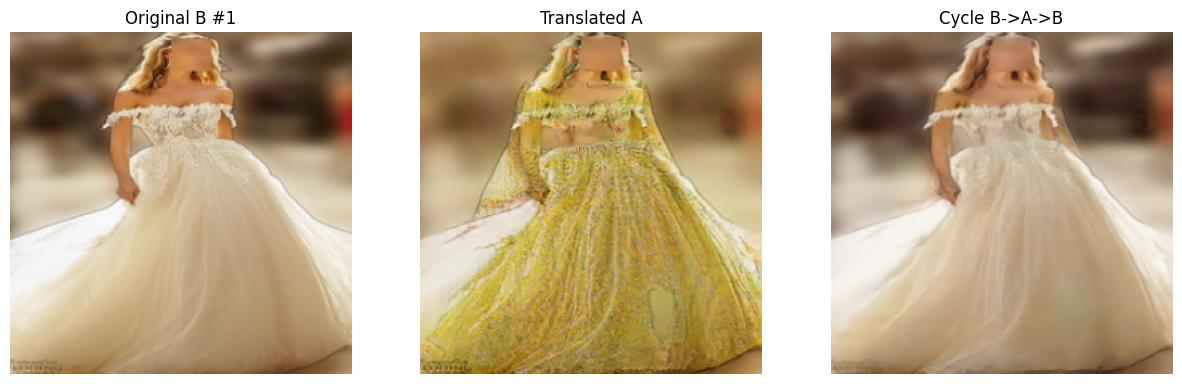

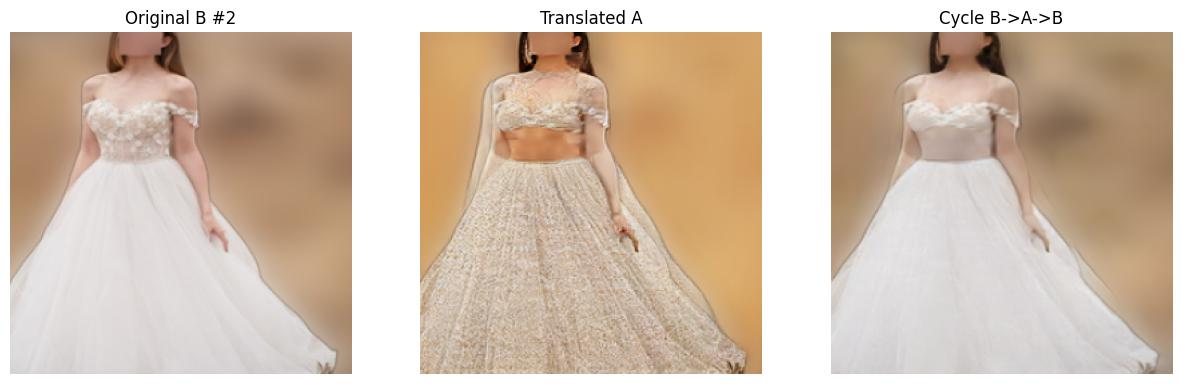

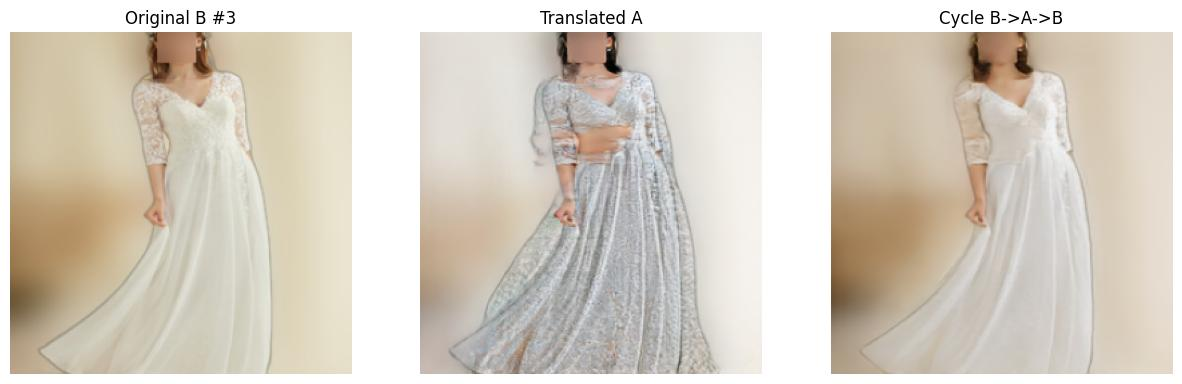

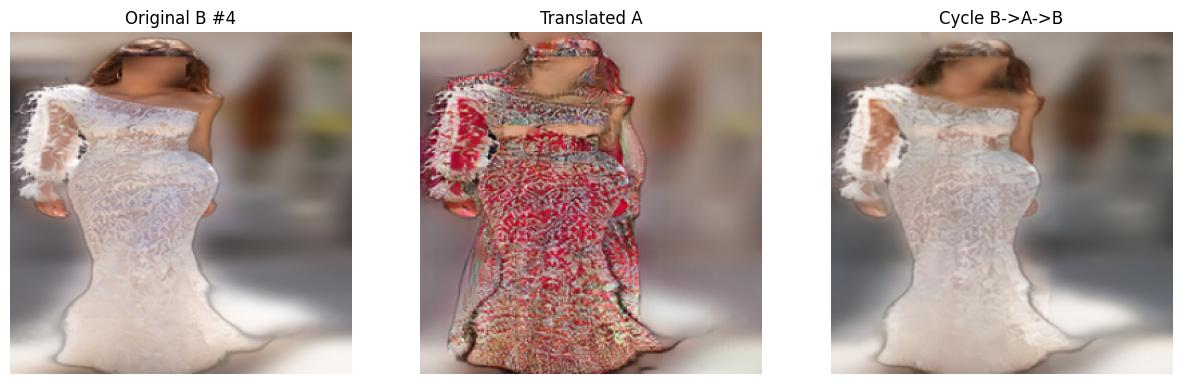

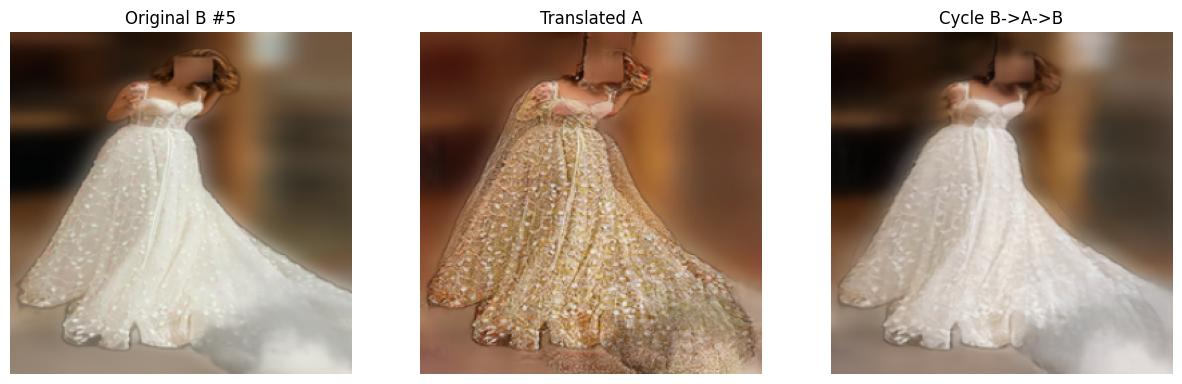

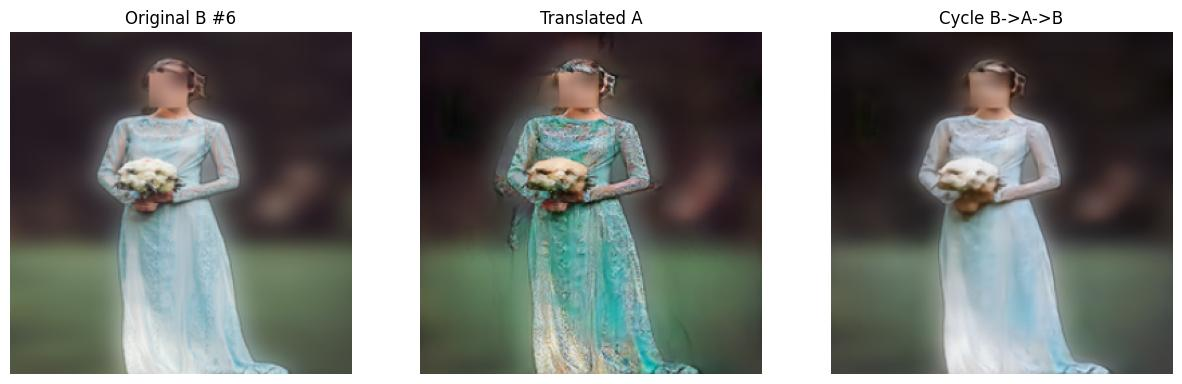

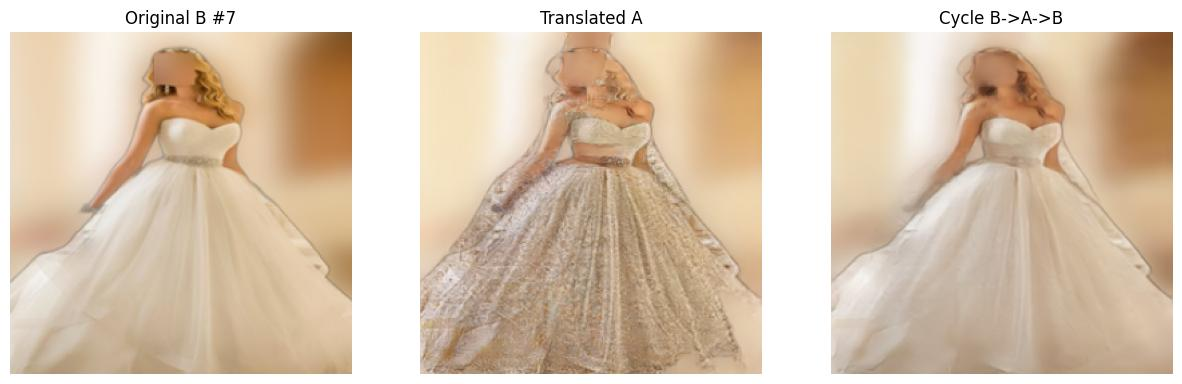

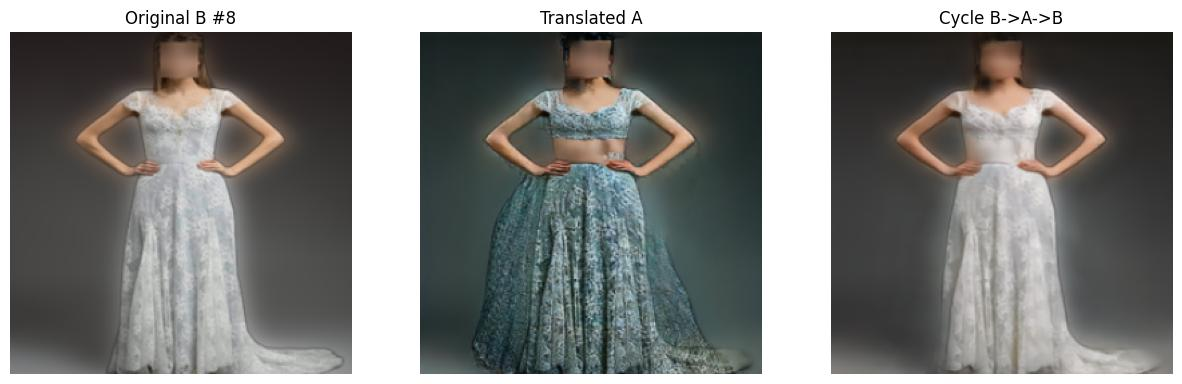

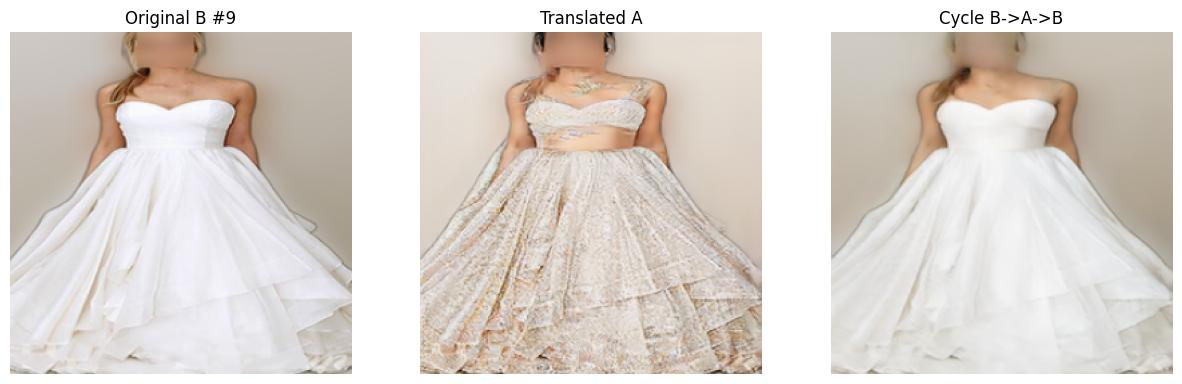

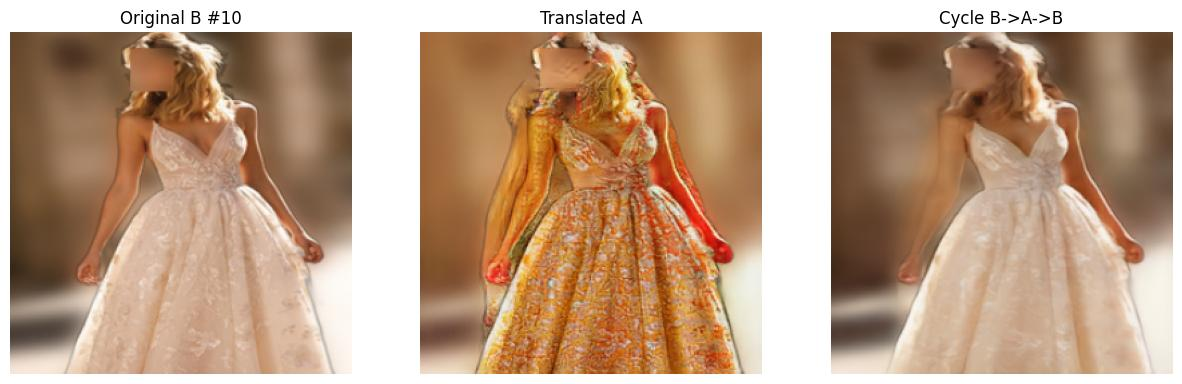

In [ ]:
import os
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch

# ----------------------------
# Paths & preprocessing
# ----------------------------
dataset_B = "/content/drive/MyDrive/CycleGAN_Project/dataset/trainB"
image_paths = sorted([os.path.join(dataset_B, f)
                      for f in os.listdir(dataset_B)
                      if f.endswith(('.jpg','.png'))])

transform = transforms.Compose([
    transforms.Resize((286, 286)),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

# ----------------------------
# Translate & reconstruct
# ----------------------------
G_A = model.netG_A  # A -> B
G_B = model.netG_B  # B -> A

num_images = 10  # number of images to process

for i, img_path in enumerate(image_paths[50:60]):
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).cuda()  # add batch dim

    with torch.no_grad():
        # B -> A
        fake_A = G_B(img_tensor)
        # A -> B (cycle reconstruction)
        rec_B = G_A(fake_A)

    # Convert to display
    def to_display(tensor):
        return ((tensor[0].cpu().permute(1,2,0).numpy() + 1)/2)

    real_B_disp = to_display(img_tensor)
    fake_A_disp = to_display(fake_A)
    rec_B_disp = to_display(rec_B)

    # Plot Original B -> Translated A -> Cycle B
    fig, axs = plt.subplots(1, 3, figsize=(15,5))
    axs[0].imshow(real_B_disp)
    axs[0].set_title(f'Original B #{i+1}')
    axs[0].axis('off')
    axs[1].imshow(fake_A_disp)
    axs[1].set_title('Translated A')
    axs[1].axis('off')
    axs[2].imshow(rec_B_disp)
    axs[2].set_title('Cycle B->A->B')
    axs[2].axis('off')
    plt.show()


**Observations:**  
The translations from **Western bridal → Indian bridal** show that the model is still refining details such as **color tones and embroidery patterns**. Overall, the model produces **visually coherent translations**, especially considering that this direction carries a higher risk of **mode collapse** due to the minimalism → maximalism mapping.



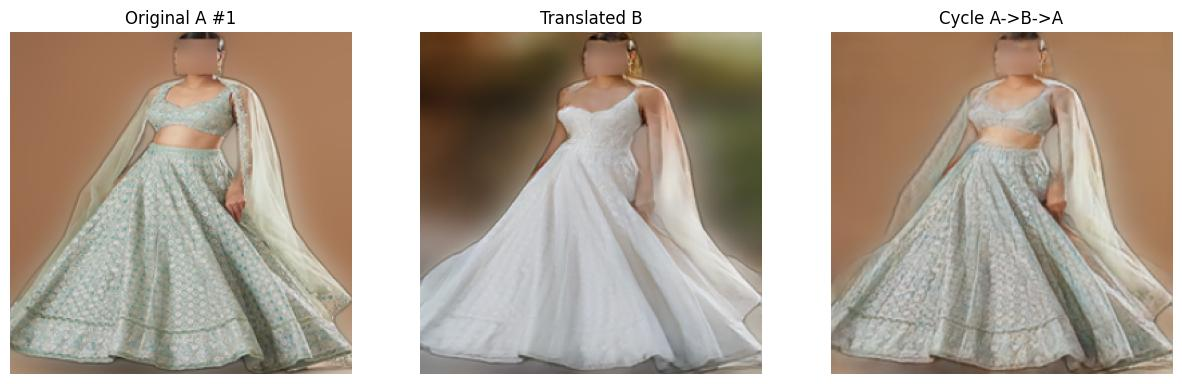

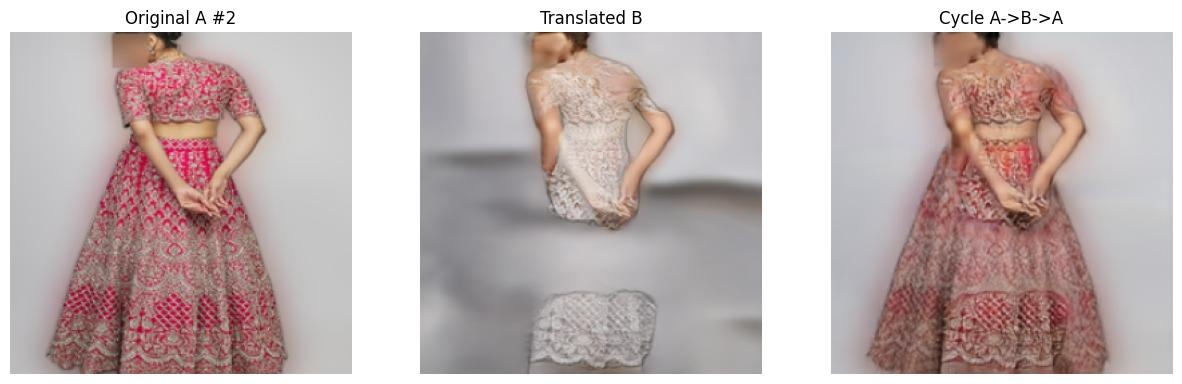

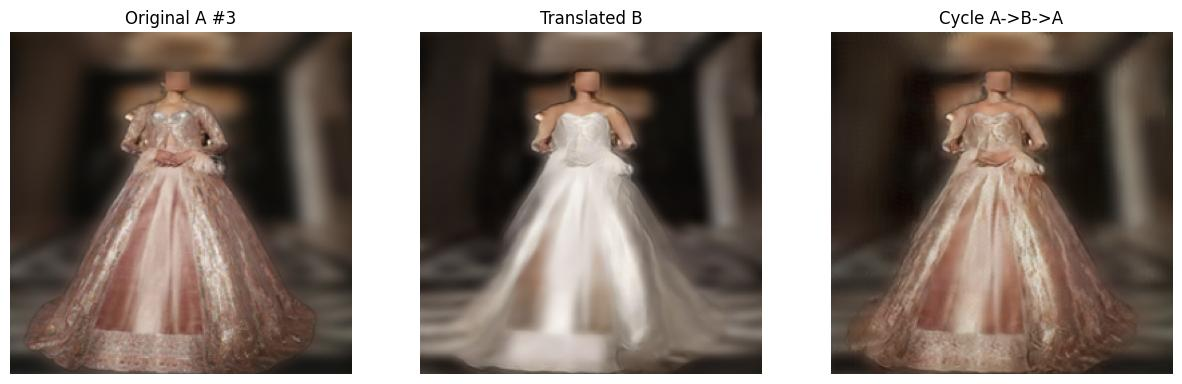

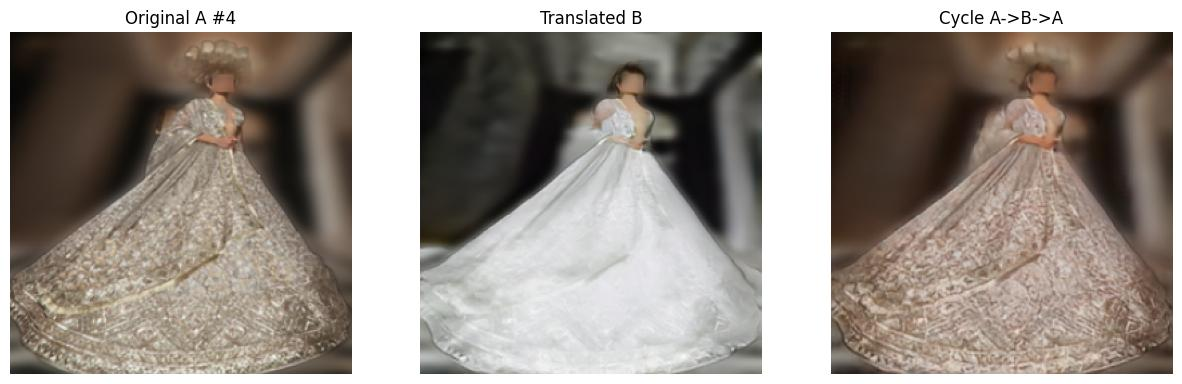

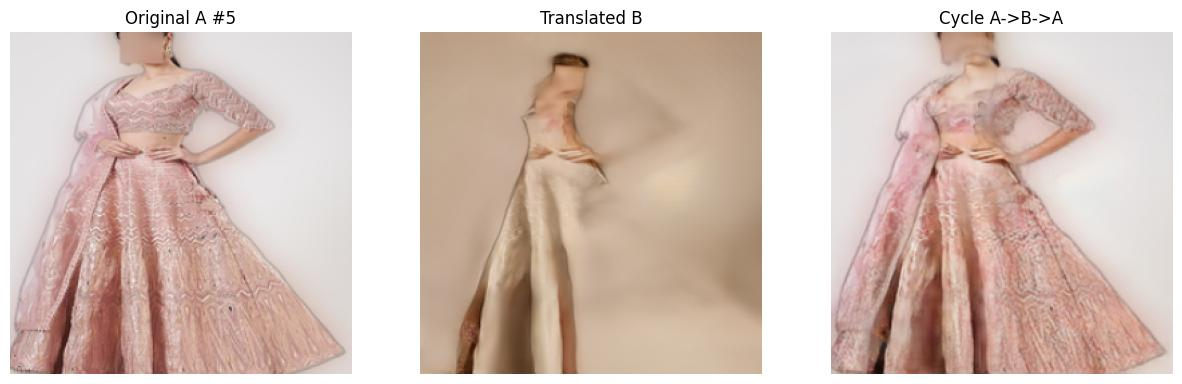

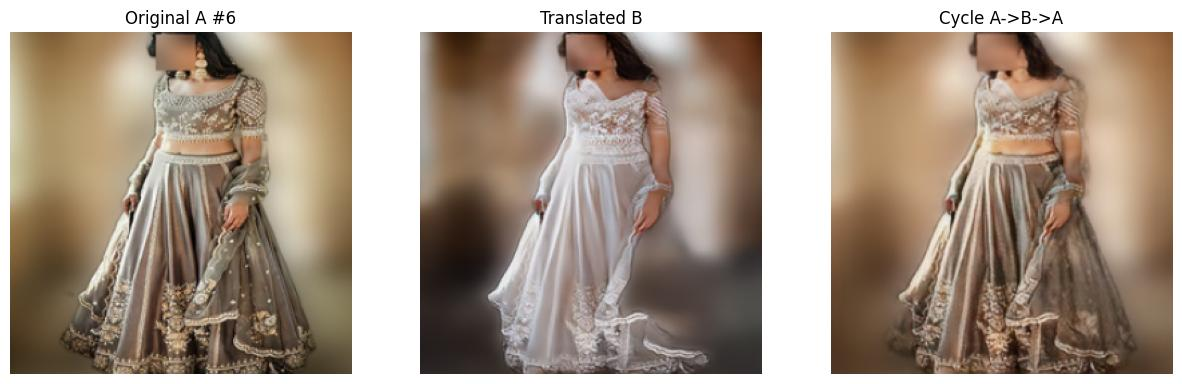

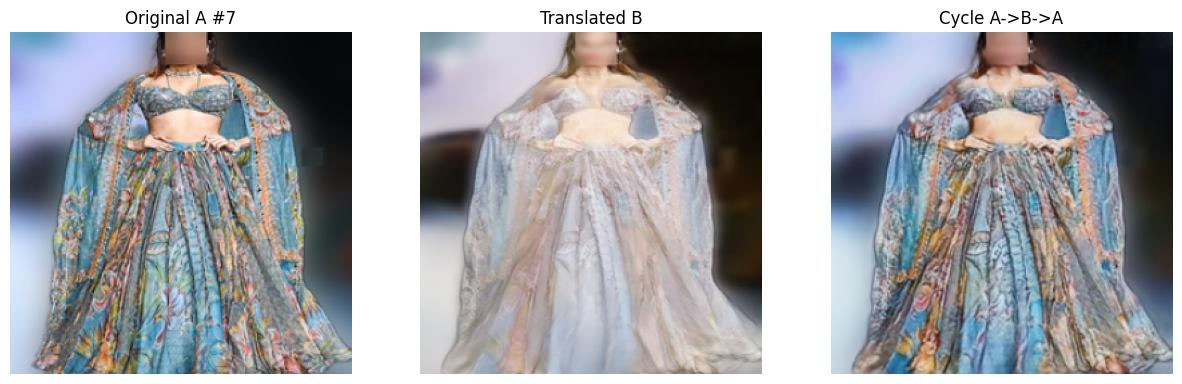

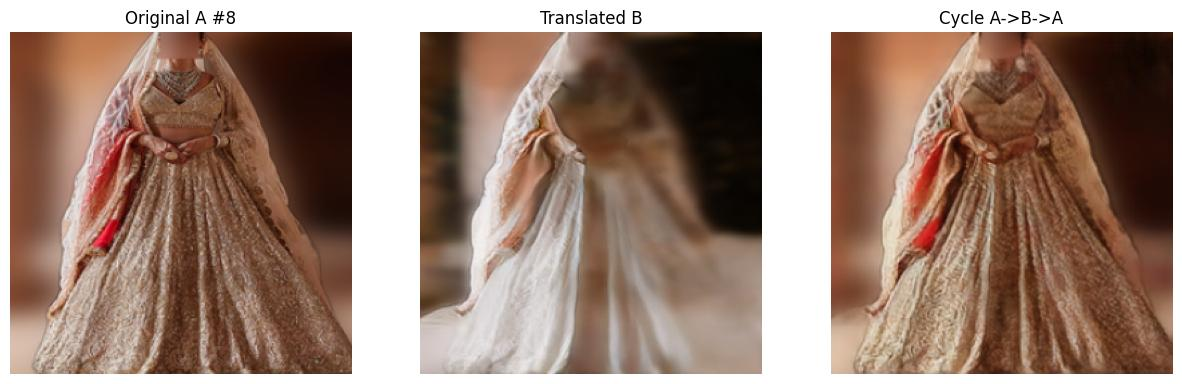

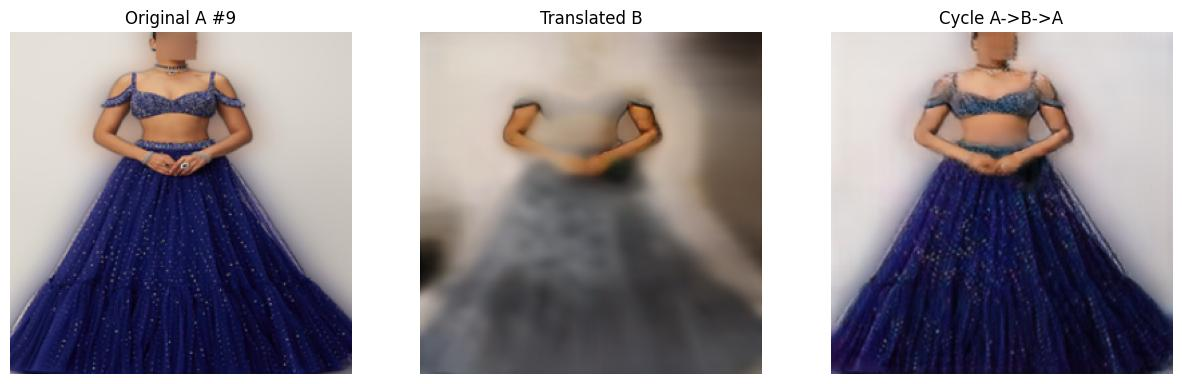

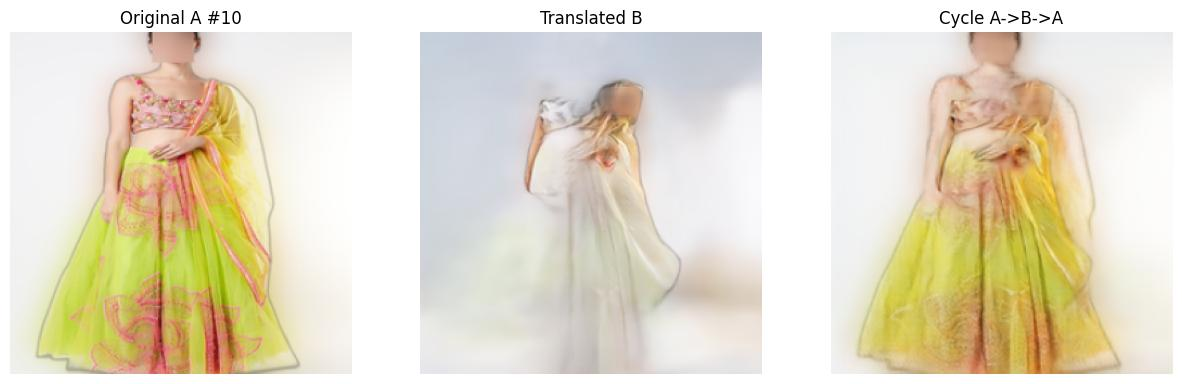

In [ ]:
import os
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch

# ----------------------------
# Paths & preprocessing
# ----------------------------
dataset_A = "/content/drive/MyDrive/CycleGAN_Project/dataset/trainA"
image_paths = sorted([os.path.join(dataset_A, f)
                      for f in os.listdir(dataset_A)
                      if f.endswith(('.jpg', '.png'))])

transform = transforms.Compose([
    transforms.Resize((286, 286)),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# ----------------------------
# Translate & reconstruct (A -> B -> A)
# ----------------------------
G_A = model.netG_A  # A -> B
G_B = model.netG_B  # B -> A

num_images = 10  # number of images to process

for i, img_path in enumerate(image_paths[70:80]):
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).cuda()  # add batch dim

    with torch.no_grad():
        # A -> B
        fake_B = G_A(img_tensor)
        # B -> A (cycle reconstruction)
        rec_A = G_B(fake_B)

    # Convert to display
    def to_display(tensor):
        return ((tensor[0].cpu().permute(1, 2, 0).numpy() + 1) / 2)

    real_A_disp = to_display(img_tensor)
    fake_B_disp = to_display(fake_B)
    rec_A_disp = to_display(rec_A)

    # Plot Original A -> Translated B -> Cycle A
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(real_A_disp)
    axs[0].set_title(f'Original A #{i+1}')
    axs[0].axis('off')
    axs[1].imshow(fake_B_disp)
    axs[1].set_title('Translated B')
    axs[1].axis('off')
    axs[2].imshow(rec_A_disp)
    axs[2].set_title('Cycle A->B->A')
    axs[2].axis('off')
    plt.show()


**Observations:**  
The **Indian → Western bridal translations** might seem poor at first glance. This is due to **background blurring/segmentation** using `rembg`, which also blurred parts of some skirts in the Western dataset, introducing **noise**. This noise is now **exaggerated in the translations**, partly because training stopped at **161 epochs** instead of the planned 200–300.  

Despite this, the translations are still **coherent**, even if they appear visually less plausible, because the blurring reflects the dataset itself. This contrasts with the Fashion-MNIST CycleGAN translations, which sometimes produced **unconventional outputs** unrelated to the dataset.


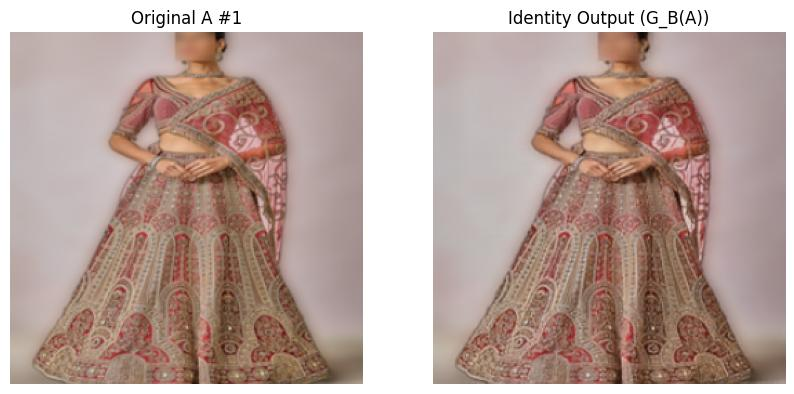

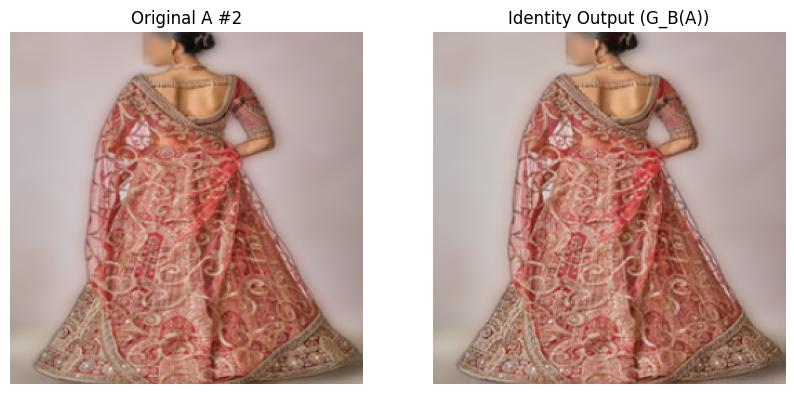

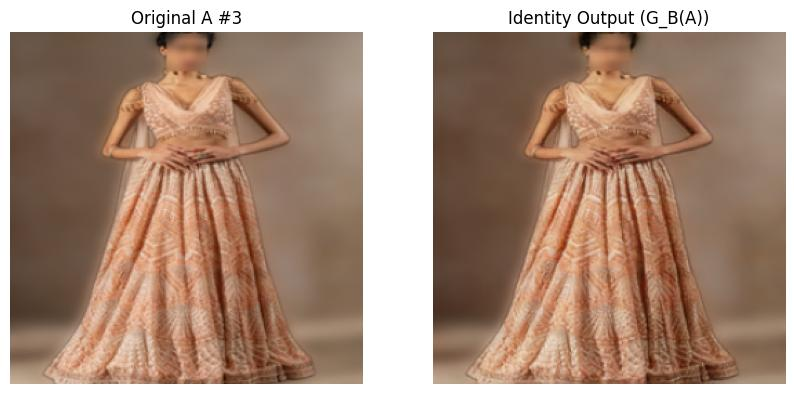

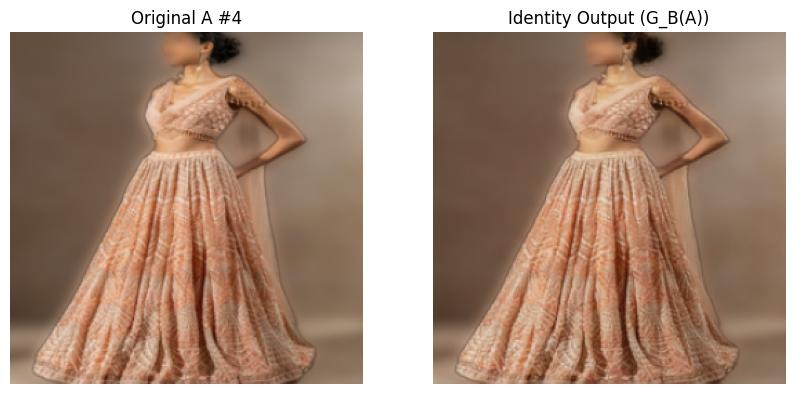

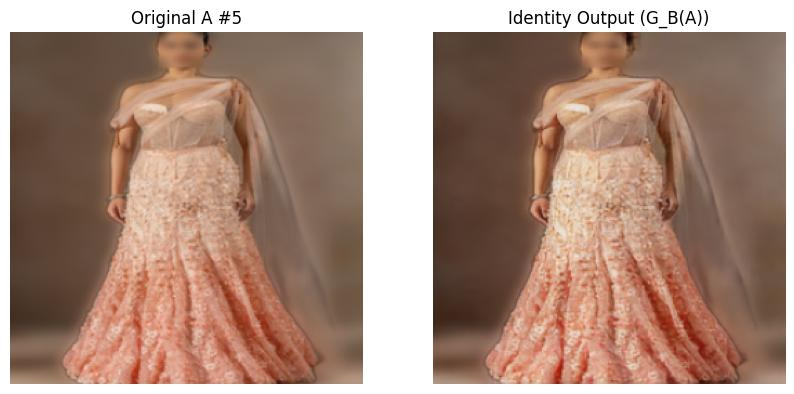

In [ ]:
import os
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch

# ----------------------------
# Paths & preprocessing
# ----------------------------
dataset_A = "/content/drive/MyDrive/CycleGAN_Project/dataset/trainA"
dataset_B = "/content/drive/MyDrive/CycleGAN_Project/dataset/trainB"

transform = transforms.Compose([
    transforms.Resize((286, 286)),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

def to_display(tensor):
    return ((tensor[0].cpu().permute(1,2,0).numpy() + 1)/2)

# ----------------------------
# 1️⃣ Identity for A images using G_B (B->A generator)
# ----------------------------
G_B.eval()
image_paths_A = sorted([os.path.join(dataset_A, f) for f in os.listdir(dataset_A) if f.endswith(('.jpg','.png'))])

for i, img_path in enumerate(image_paths_A[:5]):  # plot first 20
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).cuda()

    with torch.no_grad():
        identity_A = G_B(img_tensor)  # feed A into B->A generator

    fig, axs = plt.subplots(1, 2, figsize=(10,5))
    axs[0].imshow(to_display(img_tensor))
    axs[0].set_title(f'Original A #{i+1}')
    axs[0].axis('off')
    axs[1].imshow(to_display(identity_A))
    axs[1].set_title('Identity Output (G_B(A))')
    axs[1].axis('off')
    plt.show()




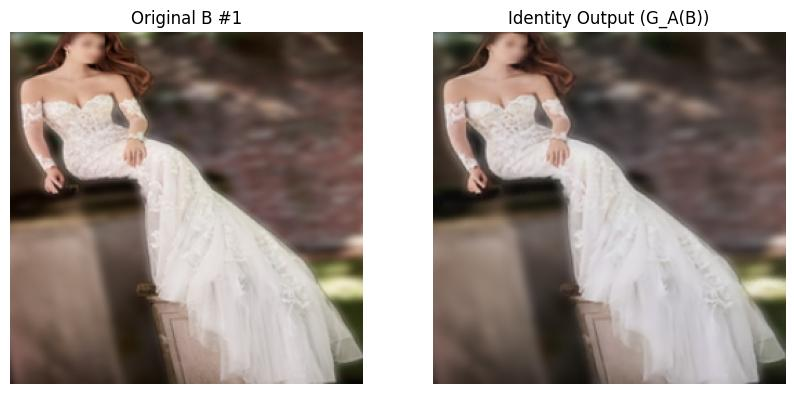

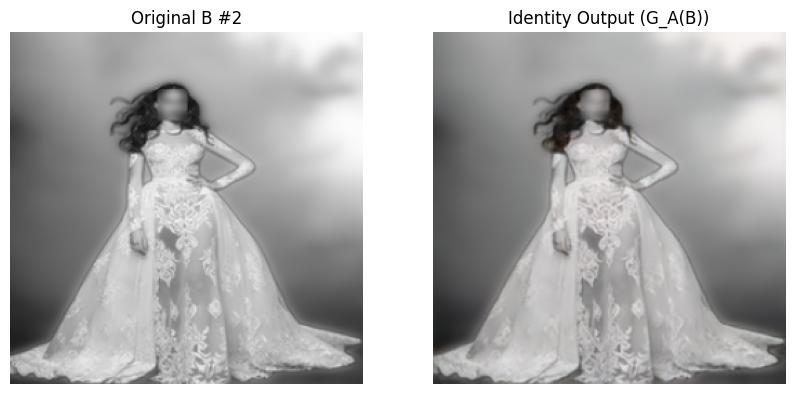

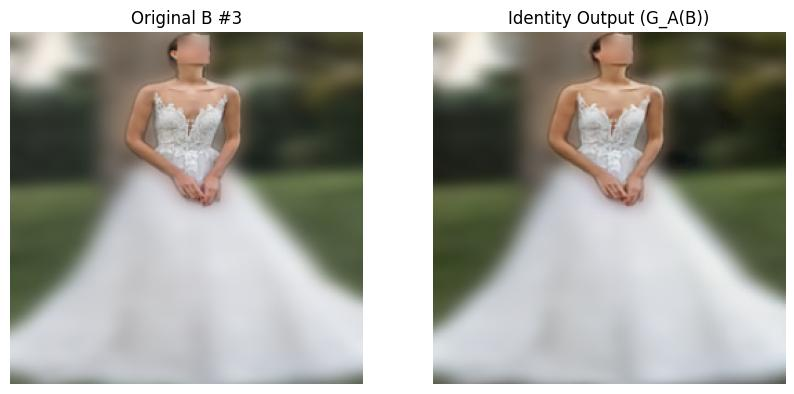

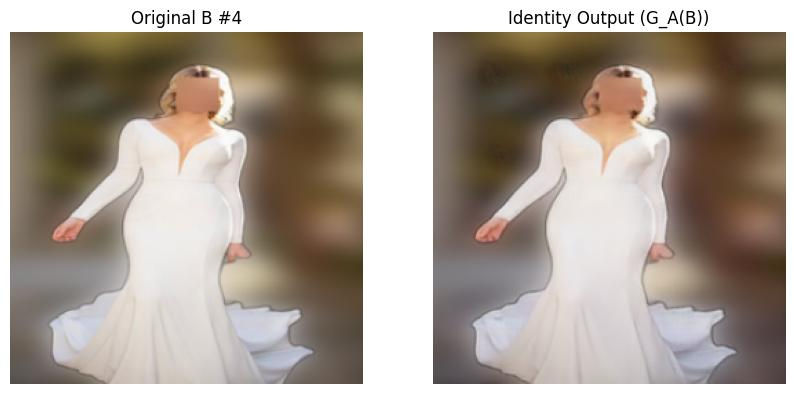

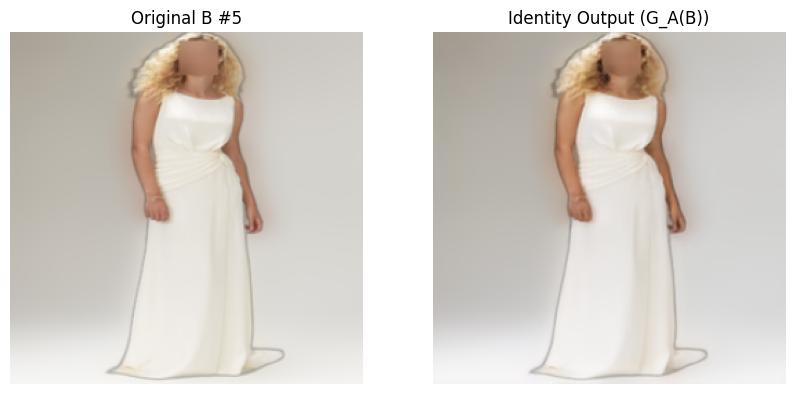

In [ ]:
# ----------------------------
# Identity for B images using G_A (A->B generator)
# ----------------------------
G_A.eval()
image_paths_B = sorted([os.path.join(dataset_B, f) for f in os.listdir(dataset_B) if f.endswith(('.jpg','.png'))])

for i, img_path in enumerate(image_paths_B[100:105]):  # plot first 20
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).cuda()

    with torch.no_grad():
        identity_B = G_A(img_tensor)  # feed B into A->B generator

    fig, axs = plt.subplots(1, 2, figsize=(10,5))
    axs[0].imshow(to_display(img_tensor))
    axs[0].set_title(f'Original B #{i+1}')
    axs[0].axis('off')
    axs[1].imshow(to_display(identity_B))
    axs[1].set_title('Identity Output (G_A(B))')
    axs[1].axis('off')
    plt.show()

**Observations:**  
The **identity outputs** for both the domains are very good, even though the model was not explicitly optimized for **identity loss**. This indicates that the model has learned **high-level semantic features**, allowing it to preserve the structure when the source image and target domain are the same.


## **5. Evaluation Metrics**

To quantitatively evaluate the quality of the generated images, we use the following metrics:

### **1. Mean Squared Error (MSE)**
- It measures the average squared difference between corresponding pixels of the generated and reference images.  
- Lower MSE indicates that the generated image is closer to the reference image.  

### **2. Structural Similarity Index (SSIM)**
- It measures the perceptual similarity between two images, focusing on luminance, contrast, and structure.  
- It ranges from -1 to 1, closer to 1 indicates higher structural similarity.  
- It is more aligned with human perception than MSE.  

### **3. Peak Signal-to-Noise Ratio (PSNR)**
- It measures the ratio between the maximum possible pixel value and the power of the noise (error) in the generated image.  
- A higher PSNR indicates better quality (less error).   

In [ ]:
import os
from PIL import Image
import torch
import torchvision.transforms as transforms
import numpy as np
from skimage.metrics import structural_similarity as ssim
from math import log10

# ----------------------------
# Paths
# ----------------------------
dataset_A = "/content/drive/MyDrive/CycleGAN_Project/dataset/trainA"
dataset_B = "/content/drive/MyDrive/CycleGAN_Project/dataset/trainB"

image_paths_A = sorted([os.path.join(dataset_A, f) for f in os.listdir(dataset_A) if f.endswith(('.jpg','.png'))])
image_paths_B = sorted([os.path.join(dataset_B, f) for f in os.listdir(dataset_B) if f.endswith(('.jpg','.png'))])

# ----------------------------
# Preprocessing
# ----------------------------
transform = transforms.Compose([
    transforms.Resize((286, 286)),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

# ----------------------------
# Metrics storage
# ----------------------------
mse_A, psnr_A, ssim_A = [], [], []
mse_B, psnr_B, ssim_B = [], [], []

# ----------------------------
# Device
# ----------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
G_A = model.netG_A.to(device).eval()  # A -> B
G_B = model.netG_B.to(device).eval()  # B -> A

# ----------------------------
# Helper functions
# ----------------------------
def to_numpy(tensor):
    return (tensor[0].cpu().permute(1,2,0).numpy() + 1)/2  # from [-1,1] to [0,1]



def compute_metrics(original, reconstructed):
    """
    original, reconstructed: numpy arrays, shape (H,W,3), values [0,1]
    """
    mse_val = np.mean((original - reconstructed) ** 2)
    psnr_val = 10 * log10(1 / mse_val) if mse_val != 0 else 100
    ssim_val = ssim(
        original,
        reconstructed,
        multichannel=True,
        channel_axis=2,
        win_size=7,
        data_range=1.0  # required for float images in [0,1]
    )
    return mse_val, psnr_val, ssim_val



# ----------------------------
# Cycle A -> B -> A
# ----------------------------
for img_path in image_paths_A[:100]:
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        fake_B = G_A(img_tensor)
        cycle_A_img = G_B(fake_B)

    orig_np = to_numpy(img_tensor)
    recon_np = to_numpy(cycle_A_img)

    m, p, s = compute_metrics(orig_np, recon_np)
    mse_A.append(m)
    psnr_A.append(p)
    ssim_A.append(s)

# ----------------------------
# Cycle B -> A -> B
# ----------------------------
for img_path in image_paths_B[:100]:
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        fake_A = G_B(img_tensor)
        cycle_B_img = G_A(fake_A)

    orig_np = to_numpy(img_tensor)
    recon_np = to_numpy(cycle_B_img)

    m, p, s = compute_metrics(orig_np, recon_np)
    mse_B.append(m)
    psnr_B.append(p)
    ssim_B.append(s)

# ----------------------------
# Print summary
# ----------------------------
print("Cycle A->B->A Metrics:")
print(f"Average MSE: {np.mean(mse_A):.6f}, PSNR: {np.mean(psnr_A):.2f}, SSIM: {np.mean(ssim_A):.4f}")

print("Cycle B->A->B Metrics:")
print(f"Average MSE: {np.mean(mse_B):.6f}, PSNR: {np.mean(psnr_B):.2f}, SSIM: {np.mean(ssim_B):.4f}")


Cycle A->B->A Metrics:
Average MSE: 0.001475, PSNR: 28.65, SSIM: 0.8983
Cycle B->A->B Metrics:
Average MSE: 0.000882, PSNR: 30.84, SSIM: 0.9454


**Observations:**  
The **cycle reconstruction metrics** are good, with **low MSE**, **decent PSNR**, and **high SSIM**. Combined with the visual translations, and compared to Fashion-MNIST, this indicates that the generator is producing **more creative translations**, even if it's at the cost of a perfect cycle reconstruction.  

The cycle reconstruction metrics are **better for domain B**, which is expected since the **Western bridal domain is simpler**.


In [ ]:
import os
from PIL import Image
import torch
import torchvision.transforms as transforms
import numpy as np
from skimage.metrics import mean_squared_error, peak_signal_noise_ratio, structural_similarity

# ======== CONFIG ========
dataset_A = "/content/drive/MyDrive/CycleGAN_Project/dataset/trainA"
dataset_B = "/content/drive/MyDrive/CycleGAN_Project/dataset/trainB"
num_images = 100  # number of images to evaluate
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ======== TRANSFORMS ========
transform = transforms.Compose([
    transforms.Resize((286, 286)),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

# ======== HELPERS ========
def to_numpy(tensor):
    return (tensor.cpu().permute(1,2,0).numpy() + 1)/2

def compute_metrics(orig, out):
    mse = mean_squared_error(orig, out)
    psnr = peak_signal_noise_ratio(orig, out, data_range=1.0)
    ssim = structural_similarity(orig, out, channel_axis=2, data_range=1.0)
    return mse, psnr, ssim

# ======== LOAD IMAGE PATHS ========
paths_A = sorted([os.path.join(dataset_A, f) for f in os.listdir(dataset_A) if f.endswith(('.jpg','.png'))])[:num_images]
paths_B = sorted([os.path.join(dataset_B, f) for f in os.listdir(dataset_B) if f.endswith(('.jpg','.png'))])[:num_images]

# ======== GENERATORS ========
G_A = model.netG_A.to(device)  # A -> B
G_B = model.netG_B.to(device)  # B -> A

# ======== EVALUATION ========
metrics_A = {'MSE':[], 'PSNR':[], 'SSIM':[]}
metrics_B = {'MSE':[], 'PSNR':[], 'SSIM':[]}

# ---- Identity for A images (feed into G_B) ----
for path in paths_A:
    img = Image.open(path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        out = G_B(img_tensor)  # identity

    orig_np = to_numpy(img_tensor[0])
    out_np = to_numpy(out[0])

    mse, psnr, ssim = compute_metrics(orig_np, out_np)
    metrics_A['MSE'].append(mse)
    metrics_A['PSNR'].append(psnr)
    metrics_A['SSIM'].append(ssim)

# ---- Identity for B images (feed into G_A) ----
for path in paths_B:
    img = Image.open(path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        out = G_A(img_tensor)  # identity

    orig_np = to_numpy(img_tensor[0])
    out_np = to_numpy(out[0])

    mse, psnr, ssim = compute_metrics(orig_np, out_np)
    metrics_B['MSE'].append(mse)
    metrics_B['PSNR'].append(psnr)
    metrics_B['SSIM'].append(ssim)

# ======== AVERAGE METRICS ========
print("\n=== Average Identity Metrics ===")
print("\nFor A images (Identity through G_B):")
for k, v in metrics_A.items():
    print(f"{k}: {np.mean(v):.4f}")

print("\nFor B images (Identity through G_A):")
for k, v in metrics_B.items():
    print(f"{k}: {np.mean(v):.4f}")



=== Average Identity Metrics ===

For A images (Identity through G_B):
MSE: 0.0005
PSNR: 33.2790
SSIM: 0.9641

For B images (Identity through G_A):
MSE: 0.0005
PSNR: 34.1482
SSIM: 0.9767


**Observations:**  
Quantitatively, the **identity mappings** are good, with **extremely low MSE**, **decent PSNR**, and **high SSIM**. This indicates that the **structure is preserved well**, even if there are some perceptual differences.


In [ ]:
!pip install pytorch-fid

In [ ]:
import os
import sys
import torch
from pytorch_fid.fid_score import calculate_fid_given_paths

# ======== CONFIG ========
real_A_dir = "/content/drive/MyDrive/CycleGAN_Project/dataset/trainA"
real_B_dir = "/content/drive/MyDrive/CycleGAN_Project/dataset/trainB"
gen_dir = "/content/drive/MyDrive/CycleGAN_Project/dataset/generated_images"
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ======== HELPER: suppress tqdm ========
class HiddenPrints:
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')
    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout

# ======== COMPUTE FID (quietly) ========
with HiddenPrints():
    fid_A2B = calculate_fid_given_paths([real_B_dir, gen_dir], batch_size=50, device=device, dims=2048)
    fid_B2A = calculate_fid_given_paths([real_A_dir, gen_dir], batch_size=50, device=device, dims=2048)

# ======== PRINT RESULTS ========
print(f"FID (A→B): {fid_A2B:.2f}")
print(f"FID (B→A): {fid_B2A:.2f}")


100%|██████████| 49/49 [00:19<00:00,  2.46it/s]


FID (A→B): 37.72
FID (B→A): 43.09


## FID (Fréchet Inception Distance)
It measures the distance between the real and the generated image distributions in feature space. Lower indicates more realism.

**Observations:**  
The FID scores are relatively high because the model **could not complete the training** to produce fully realistic images. Nonetheless, given the circumstances, they are **decent scores**.  

The FID for **B → A** is higher, which is expected, since the **minimalism → maximalism direction** is inherently more challenging.


##Inception Score (IS)
Evaluates both quality and diversity of generated images. A higher value indicates realistic and diverse outputs.

In [ ]:
#Imports
import torch
import torchvision.transforms as transforms
from torchvision.models import inception_v3
from PIL import Image
import os
import numpy as np
from torch.nn import functional as F

#Helper: load images
def load_images(folder, transform):
    images = []
    for f in sorted(os.listdir(folder)):
        if f.endswith(('.jpg', '.png')):
            img = Image.open(os.path.join(folder, f)).convert('RGB')
            images.append(transform(img))
    return torch.stack(images)

#Preprocessing
transform = transforms.Compose([
    transforms.Resize((299, 299)),  # Inception input size
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

#Load generated images
gen_folder = "/content/drive/MyDrive/CycleGAN_Project/dataset/generated_images"
images = load_images(gen_folder, transform)  # shape: [N,3,299,299]
images = images.cuda()

#Load InceptionV3
inception = inception_v3(pretrained=True, transform_input=False).eval().cuda()
inception.fc = torch.nn.Identity()  # Remove final fc layer to get features

#Compute softmax probabilities
batch_size = 50
all_probs = []
with torch.no_grad():
    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]
        logits = inception(batch)
        probs = F.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
all_probs = np.concatenate(all_probs, axis=0)  # [N, 1000]

#Compute IS
from scipy.stats import entropy

split = 10
N = all_probs.shape[0]
scores = []
for k in range(split):
    part = all_probs[k * (N // split): (k+1) * (N // split), :]
    p_y = np.mean(part, axis=0)
    kl = part * (np.log(part + 1e-16) - np.log(p_y + 1e-16))
    kl_sum = np.sum(kl, axis=1)
    scores.append(np.exp(np.mean(kl_sum)))

inception_score = np.mean(scores)
print(f"Inception Score: {inception_score:.2f}")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 178MB/s]


Inception Score: 1.04


**Observations:**  
The **Inception Score (IS)** is **1.04**, which is extremely low. This is expected because:  
- The images are **high-resolution bridal images**, while the **Inception network was trained on natural images (ImageNet, 224×224)**.  
- Due to this domain mismatch, the classifier **fails to confidently assign meaningful class probabilities**, resulting in a very low IS.  
- Therefore, the IS in this case **does not accurately reflect visual quality or diversity** of the generated images.


## LPIPS (Learned Perceptual Image Patch Similarity)
Measures perceptual similarity between images. Lower value indicates lesser error.

In [ ]:
!pip install lpips

In [ ]:
import lpips
import torch
from PIL import Image
import os
import torchvision.transforms as transforms
import numpy as np

# Initialize LPIPS model (AlexNet backbone)
loss_fn = lpips.LPIPS(net='alex').cuda()

# Transform to normalize images to [-1,1]
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

# Helper to convert tensor to numpy for plotting
def to_numpy(tensor):
    return (tensor.cpu().permute(1,2,0).numpy() + 1)/2

# Paths to datasets
dataset_A = "/content/drive/MyDrive/CycleGAN_Project/dataset/trainA"
dataset_B = "/content/drive/MyDrive/CycleGAN_Project/dataset/trainB"

image_paths_A = sorted([os.path.join(dataset_A, f) for f in os.listdir(dataset_A) if f.endswith(('.jpg','.png'))])
image_paths_B = sorted([os.path.join(dataset_B, f) for f in os.listdir(dataset_B) if f.endswith(('.jpg','.png'))])

# Store LPIPS values
lpips_A = []
lpips_B = []

# ---- Identity LPIPS (optional) ----
for i, img_path in enumerate(image_paths_A[:100]):  # adjust number as needed
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).cuda()

    with torch.no_grad():
        identity = G_B(img_tensor)
        lpips_val = loss_fn(img_tensor, identity).item()
        lpips_A.append(lpips_val)

for i, img_path in enumerate(image_paths_B[:100]):
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).cuda()

    with torch.no_grad():
        identity = G_A(img_tensor)
        lpips_val = loss_fn(img_tensor, identity).item()
        lpips_B.append(lpips_val)

print(f"Average LPIPS for A images (Identity through G_B): {np.mean(lpips_A):.4f}")
print(f"Average LPIPS for B images (Identity through G_A): {np.mean(lpips_B):.4f}")

# ---- Cycle LPIPS (A->B->A and B->A->B) ----
cycle_lpips_A = []
cycle_lpips_B = []


for i, img_path in enumerate(image_paths_A[:100]):
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).cuda()

    with torch.no_grad():
        fake_B = G_A(img_tensor)        # A->B
        recon_A = G_B(fake_B)           # B->A
        lpips_val = loss_fn(img_tensor, recon_A).item()
        cycle_lpips_A.append(lpips_val)

for i, img_path in enumerate(image_paths_B[:100]):
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).cuda()

    with torch.no_grad():
        fake_A = G_B(img_tensor)        # B->A
        recon_B = G_A(fake_A)           # A->B
        lpips_val = loss_fn(img_tensor, recon_B).item()
        cycle_lpips_B.append(lpips_val)

print(f"Average Cycle LPIPS for A images: {np.mean(cycle_lpips_A):.4f}")
print(f"Average Cycle LPIPS for B images: {np.mean(cycle_lpips_B):.4f}")


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Average LPIPS for A images (Identity through G_B): 0.0377
Average LPIPS for B images (Identity through G_A): 0.0466
Average Cycle LPIPS for A images: 0.1390
Average Cycle LPIPS for B images: 0.1048


**Observations:**  

The low values for **identity LPIPS** indicate that the **identity mappings preserve perceptual similarity** well between the source image and the output.  

The slightly higher **cycle LPIPS** values are expected, showing that while the **overall structure is preserved**, the generator introduces **perceptual changes** during domain translation, which cannot be fully reversed during reconstruction.


## Color Metrics

### RGB Histograms:
Assess distribution of color channels and overall color diversity.  

### HSV Histograms & Delta-E:

Evaluate tone, saturation, brightness, and perceptual color differences between source and translated images.  

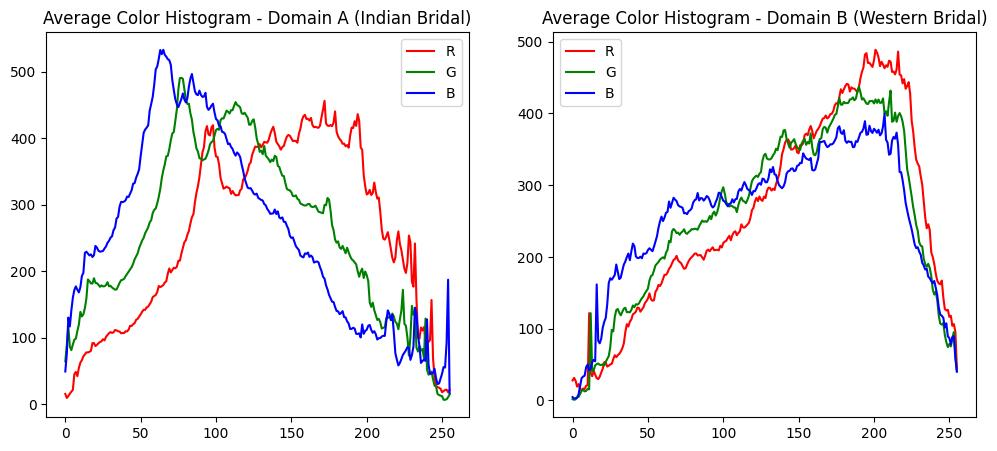

In [ ]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Paths
dataset_A = "/content/drive/MyDrive/CycleGAN_Project/dataset/trainA"
dataset_B = "/content/drive/MyDrive/CycleGAN_Project/dataset/trainB"

# Function to compute histogram per channel
def compute_color_hist(image_paths):
    r_hist, g_hist, b_hist = [], [], []
    for path in image_paths[:100]:  # limit to 100 images for quick visualization
        img = np.array(Image.open(path).convert('RGB'))
        r_hist.append(np.histogram(img[:,:,0], bins=256, range=(0,255))[0])
        g_hist.append(np.histogram(img[:,:,1], bins=256, range=(0,255))[0])
        b_hist.append(np.histogram(img[:,:,2], bins=256, range=(0,255))[0])
    return np.mean(r_hist, axis=0), np.mean(g_hist, axis=0), np.mean(b_hist, axis=0)

# Collect histograms
A_images = sorted([os.path.join(dataset_A, f) for f in os.listdir(dataset_A) if f.endswith(('.jpg','.png'))])
B_images = sorted([os.path.join(dataset_B, f) for f in os.listdir(dataset_B) if f.endswith(('.jpg','.png'))])

rA, gA, bA = compute_color_hist(A_images)
rB, gB, bB = compute_color_hist(B_images)

# Plot
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(rA, color='r', label='R')
plt.plot(gA, color='g', label='G')
plt.plot(bA, color='b', label='B')
plt.title('Average Color Histogram - Domain A (Indian Bridal)')
plt.legend()

plt.subplot(1,2,2)
plt.plot(rB, color='r', label='R')
plt.plot(gB, color='g', label='G')
plt.plot(bB, color='b', label='B')
plt.title('Average Color Histogram - Domain B (Western Bridal)')
plt.legend()

plt.show()


**Observations:**  
The **color histogram** for the **Indian bridal dataset** shows distinct RGB channel peaks, reflecting **vibrant color diversity**, while the **Western bridal dataset** exhibits overlapping peaks, indicating a **more uniform tonal palette**.


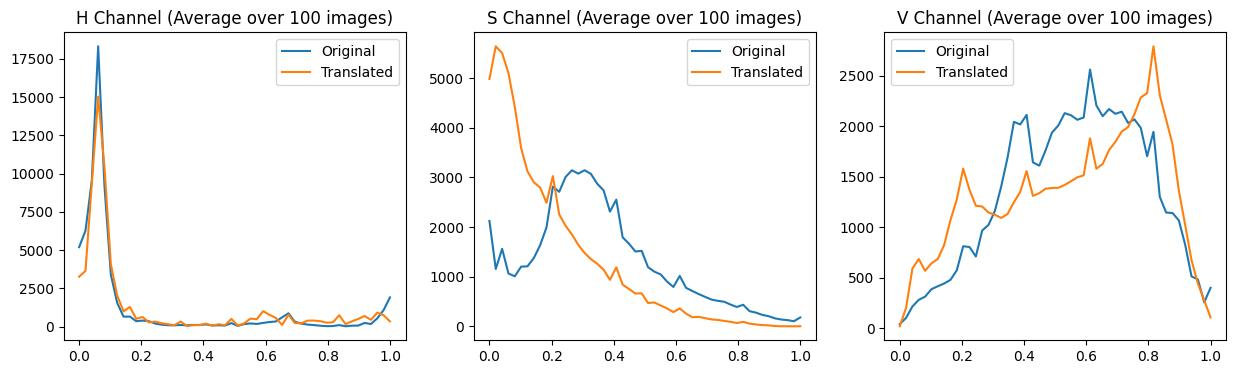

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms as transforms
import torch

# Paths
dataset_A = "/content/drive/MyDrive/CycleGAN_Project/dataset/trainA"
G_A = model.netG_A  # A -> B

# Preprocess
transform = transforms.Compose([
    transforms.Resize((286, 286)),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

def rgb_to_hsv_np(img_tensor):
    """Convert torch tensor image (C,H,W) [-1,1] to HSV numpy [0-1]"""
    img = (img_tensor.clamp(-1,1).cpu().permute(1,2,0).numpy() + 1)/2
    img = (img*255).astype(np.uint8)
    pil_img = Image.fromarray(img)
    hsv_img = pil_img.convert("HSV")
    hsv_np = np.array(hsv_img)/255.0
    return hsv_np

# Initialize accumulators
bins = 50
hists_orig = [np.zeros(bins) for _ in range(3)]
hists_trans = [np.zeros(bins) for _ in range(3)]

# Get image paths
image_paths = sorted([os.path.join(dataset_A, f) for f in os.listdir(dataset_A) if f.endswith(('.jpg','.png'))])

# Loop over first 100 images
for i, img_path in enumerate(image_paths[:100]):
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).cuda()

    # Translate
    with torch.no_grad():
        translated_tensor = G_A(img_tensor)

    # Convert to HSV
    orig_hsv = rgb_to_hsv_np(img_tensor[0])
    trans_hsv = rgb_to_hsv_np(translated_tensor[0])

    # Compute histograms per channel
    for c in range(3):
        hist_orig, _ = np.histogram(orig_hsv[:,:,c], bins=bins, range=(0,1))
        hist_trans, _ = np.histogram(trans_hsv[:,:,c], bins=bins, range=(0,1))
        hists_orig[c] += hist_orig
        hists_trans[c] += hist_trans

# Average histograms
hists_orig = [h/len(image_paths[:100]) for h in hists_orig]
hists_trans = [h/len(image_paths[:100]) for h in hists_trans]
x = np.linspace(0,1,bins)

# Plot
colors = ['H', 'S', 'V']
fig, axs = plt.subplots(1,3, figsize=(15,4))
for i, col in enumerate(colors):
    axs[i].plot(x, hists_orig[i], label='Original')
    axs[i].plot(x, hists_trans[i], label='Translated')
    axs[i].set_title(f'{col} Channel (Average over 100 images)')
    axs[i].legend()
plt.show()


**Observations:**  

The **HSV histograms** for **Indian → Western translations** show:  
- The **Hue curves** are similar, indicating that the model effectively **preserved overall color tones** during domain translation.  
- The **Saturation curve** gradually declines in the translated set, suggesting that the generator **enhanced vibrancy early on** before stabilizing it.  
- The **multi-peaked Value distribution** reflects adaptation to **varied lighting and fabric brightness**, demonstrating that the model captures **stylistic luminance contrasts** instead of just replicating texture.


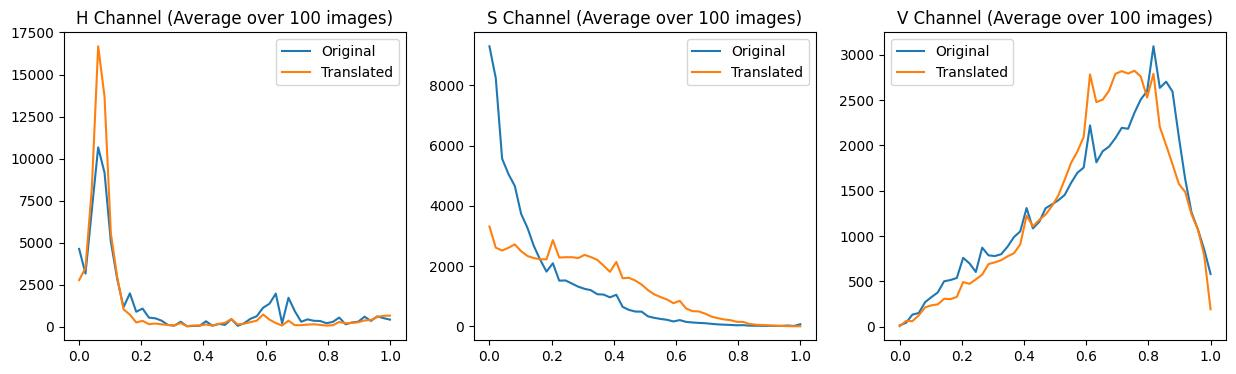

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms as transforms
import torch

# Paths
dataset_A = "/content/drive/MyDrive/CycleGAN_Project/dataset/trainB"
G_B = model.netG_B  # B -> A

# Preprocess
transform = transforms.Compose([
    transforms.Resize((286, 286)),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

def rgb_to_hsv_np(img_tensor):
    """Convert torch tensor image (C,H,W) [-1,1] to HSV numpy [0-1]"""
    img = (img_tensor.clamp(-1,1).cpu().permute(1,2,0).numpy() + 1)/2
    img = (img*255).astype(np.uint8)
    pil_img = Image.fromarray(img)
    hsv_img = pil_img.convert("HSV")
    hsv_np = np.array(hsv_img)/255.0
    return hsv_np

# Initialize accumulators
bins = 50
hists_orig = [np.zeros(bins) for _ in range(3)]
hists_trans = [np.zeros(bins) for _ in range(3)]

# Get image paths
image_paths = sorted([os.path.join(dataset_A, f) for f in os.listdir(dataset_A) if f.endswith(('.jpg','.png'))])

# Loop over first 100 images
for i, img_path in enumerate(image_paths[:100]):
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).cuda()

    # Translate
    with torch.no_grad():
        translated_tensor = G_B(img_tensor)

    # Convert to HSV
    orig_hsv = rgb_to_hsv_np(img_tensor[0])
    trans_hsv = rgb_to_hsv_np(translated_tensor[0])

    # Compute histograms per channel
    for c in range(3):
        hist_orig, _ = np.histogram(orig_hsv[:,:,c], bins=bins, range=(0,1))
        hist_trans, _ = np.histogram(trans_hsv[:,:,c], bins=bins, range=(0,1))
        hists_orig[c] += hist_orig
        hists_trans[c] += hist_trans

# Average histograms
hists_orig = [h/len(image_paths[:100]) for h in hists_orig]
hists_trans = [h/len(image_paths[:100]) for h in hists_trans]
x = np.linspace(0,1,bins)

# Plot
colors = ['H', 'S', 'V']
fig, axs = plt.subplots(1,3, figsize=(15,4))
for i, col in enumerate(colors):
    axs[i].plot(x, hists_orig[i], label='Original')
    axs[i].plot(x, hists_trans[i], label='Translated')
    axs[i].set_title(f'{col} Channel (Average over 100 images)')
    axs[i].legend()
plt.show()


**Observations:**  

The **HSV histograms** for **Western → Indian translations** show:  
- **Hue profiles** are similar, indicating **consistent tone preservation**.  
- **Saturation distribution** is subdued, suggesting the model **underrepresented color intensity** compared to the originals.  
- **Value curves** maintain comparable structure, reflecting **stable brightness mapping** despite chromatic disparities.


## Edge/Texture Metrics
   - **MSE, PSNR, SSIM on edges or Laplacian filtered images**: Evaluate structural and textural preservation.  
   - **HOG Similarity**: Measures similarity of gradient/edge features between images.

In [ ]:
import os
from PIL import Image
import numpy as np
import torch
import torchvision.transforms as transforms
from skimage import filters, metrics

# ===== PATHS =====
dataset_A = "/content/drive/MyDrive/CycleGAN_Project/dataset/trainA"
dataset_B = "/content/drive/MyDrive/CycleGAN_Project/dataset/trainB"

G_A = model.netG_A  # A -> B
G_B = model.netG_B  # B -> A

# ===== PREPROCESSING =====
transform = transforms.Compose([
    transforms.Resize((286, 286)),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

def to_numpy(tensor):
    """Convert tensor [-1,1] -> [0,1] numpy."""
    return (tensor.clamp(-1, 1).cpu().permute(1, 2, 0).numpy() + 1) / 2

def compute_edge_metrics(orig, translated):
    """Compute edge-based MSE, PSNR, and SSIM."""
    orig_gray = np.dot(orig, [0.2989, 0.5870, 0.1140])
    trans_gray = np.dot(translated, [0.2989, 0.5870, 0.1140])

    edge_orig = filters.sobel(orig_gray)
    edge_trans = filters.sobel(trans_gray)

    mse = np.mean((edge_orig - edge_trans) ** 2)
    psnr = metrics.peak_signal_noise_ratio(edge_orig, edge_trans, data_range=1.0)
    ssim = metrics.structural_similarity(edge_orig, edge_trans, data_range=1.0)
    return mse, psnr, ssim

def evaluate_edges(generator, image_paths, label):
    """Evaluate average edge preservation metrics for given generator + dataset."""
    mse_list, psnr_list, ssim_list = [], [], []

    for img_path in image_paths[:100]:  # limit to 100 images
        img = Image.open(img_path).convert('RGB')
        img_tensor = transform(img).unsqueeze(0).cuda()

        with torch.no_grad():
            translated_tensor = generator(img_tensor)

        orig_np = to_numpy(img_tensor[0])
        trans_np = to_numpy(translated_tensor[0])

        mse, psnr, ssim = compute_edge_metrics(orig_np, trans_np)
        mse_list.append(mse)
        psnr_list.append(psnr)
        ssim_list.append(ssim)

    print(f"\nEdge Preservation Metrics ({label} Translation):")
    print(f"Average MSE:  {np.mean(mse_list):.6f}")
    print(f"Average PSNR: {np.mean(psnr_list):.4f}")
    print(f"Average SSIM: {np.mean(ssim_list):.4f}")

# ===== IMAGE PATHS =====
paths_A = sorted([os.path.join(dataset_A, f) for f in os.listdir(dataset_A) if f.endswith(('.jpg', '.png'))])
paths_B = sorted([os.path.join(dataset_B, f) for f in os.listdir(dataset_B) if f.endswith(('.jpg', '.png'))])

# ===== EVALUATE BOTH DIRECTIONS =====
evaluate_edges(G_A, paths_A, "A→B")
evaluate_edges(G_B, paths_B, "B→A")



Edge Preservation Metrics (A→B Translation):
Average MSE:  0.001568
Average PSNR: 28.6769
Average SSIM: 0.6539

Edge Preservation Metrics (B→A Translation):
Average MSE:  0.001462
Average PSNR: 29.1107
Average SSIM: 0.6779


**Observations:**  

The edge metrics indicate that the model is able to **reasonably preserve edge structures** during translation. Main observations include:

- The **slightly higher SSIM and PSNR** for B → A reflect better structure preservation in the **Western → Indian** translations, due to the simpler Western silhouettes.  
- The overall low MSE values further support that **pixel-level deviations along edges are minimal**, demonstrating the generator’s ability to maintain **sharp features** while performing stylistic translations.


In [ ]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torch
import cv2
from skimage.metrics import mean_squared_error as mse
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# Paths
dataset_A = "/content/drive/MyDrive/CycleGAN_Project/dataset/trainA"
dataset_B = "/content/drive/MyDrive/CycleGAN_Project/dataset/trainB"

G_A = model.netG_A  # A->B
G_B = model.netG_B  # B->A

# Preprocess
transform = transforms.Compose([
    transforms.Resize((286, 286)),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

def to_numpy(img_tensor):
    return (img_tensor.clamp(-1,1).cpu().permute(1,2,0).numpy() + 1)/2

def laplacian_edge(img_np):
    img_gray = cv2.cvtColor((img_np*255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    lap = cv2.Laplacian(img_gray, cv2.CV_32F)
    return lap

def compute_texture_metrics(orig_np, trans_np):
    lap_orig = laplacian_edge(orig_np)
    lap_trans = laplacian_edge(trans_np)
    m = mse(lap_orig, lap_trans)
    p = psnr(lap_orig, lap_trans, data_range=lap_orig.max()-lap_orig.min())
    s = ssim(lap_orig, lap_trans, data_range=lap_orig.max()-lap_orig.min())
    return m, p, s, lap_orig, lap_trans

# Choose dataset & generator
dataset_paths = [(dataset_A, G_A, "A->B"), (dataset_B, G_B, "B->A")]

for dataset_path, generator, label in dataset_paths:
    image_paths = sorted([os.path.join(dataset_path, f) for f in os.listdir(dataset_path) if f.endswith(('.jpg','.png'))])
    mse_list, psnr_list, ssim_list = [], [], []

    for i, img_path in enumerate(image_paths[:100]):  # first 100 for speed
        img = Image.open(img_path).convert('RGB')
        img_tensor = transform(img).unsqueeze(0).cuda()

        with torch.no_grad():
            out_tensor = generator(img_tensor)

        orig_np = to_numpy(img_tensor[0])
        trans_np = to_numpy(out_tensor[0])

        m, p, s, lap_orig, lap_trans = compute_texture_metrics(orig_np, trans_np)
        mse_list.append(m)
        psnr_list.append(p)
        ssim_list.append(s)


    print(f"\nEdge/Texture (Laplacian) Metrics ({label} translation) over {len(mse_list)} images:")
    print(f"Average MSE: {np.mean(mse_list):.6f}")
    print(f"Average PSNR: {np.mean(psnr_list):.4f}")
    print(f"Average SSIM: {np.mean(ssim_list):.4f}\n")



Edge/Texture (Laplacian) Metrics (A->B translation) over 100 images:
Average MSE: 469.390335
Average PSNR: 27.3517
Average SSIM: 0.6616


Edge/Texture (Laplacian) Metrics (B->A translation) over 100 images:
Average MSE: 582.834213
Average PSNR: 23.7748
Average SSIM: 0.6026



**Observations**

The Laplacian metrics indicate how well the model preserves **edges and texture details** during translation.  
- **A → B** has lower MSE and higher PSNR and SSIM, which suggests a **better texture preservation** for Indian → Western translations.  
- **B → A** shows slightly worse performance, which might be due to the **texture complexity of the Indian bridal attire**, making it harder for the generator to reproduce fine-grained details while translating from Western → Indian domain.

Average HOG similarity A->B: 0.8213
Average HOG similarity B->A: 0.8325


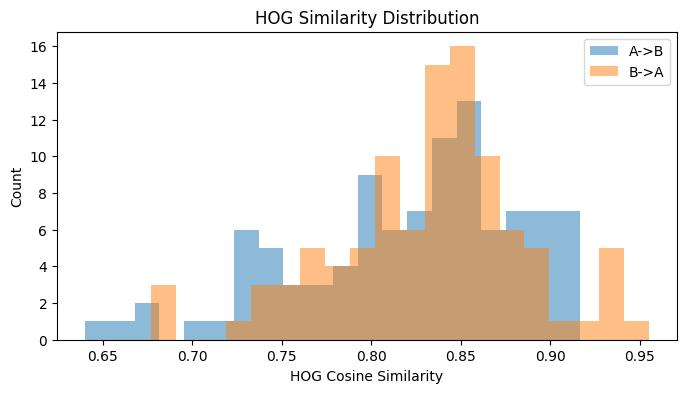

In [ ]:
import os
from PIL import Image
import numpy as np
import torch
import torchvision.transforms as transforms
from skimage.feature import hog
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# Paths
dataset_A = "/content/drive/MyDrive/CycleGAN_Project/dataset/trainA"
dataset_B = "/content/drive/MyDrive/CycleGAN_Project/dataset/trainB"

G_A = model.netG_A  # A -> B
G_B = model.netG_B  # B -> A

# Preprocess
transform = transforms.Compose([
    transforms.Resize((286, 286)),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

def to_numpy(img_tensor):
    """Convert [-1,1] tensor to [0,1] numpy"""
    return (img_tensor.clamp(-1,1).cpu().permute(1,2,0).numpy() + 1)/2

def compute_hog_similarity(orig, translated):
    """Compute cosine similarity between HOG descriptors"""
    # Convert to grayscale
    orig_gray = np.dot(orig[...,:3], [0.299,0.587,0.114])
    trans_gray = np.dot(translated[...,:3], [0.299,0.587,0.114])

    hog_orig = hog(orig_gray, pixels_per_cell=(16,16), cells_per_block=(2,2), feature_vector=True)
    hog_trans = hog(trans_gray, pixels_per_cell=(16,16), cells_per_block=(2,2), feature_vector=True)

    # Cosine similarity
    sim = cosine_similarity(hog_orig.reshape(1,-1), hog_trans.reshape(1,-1))[0,0]
    return sim

# Function to process dataset
def compute_hog_dataset(dataset_path, G, num_images=100):
    image_paths = sorted([os.path.join(dataset_path, f)
                          for f in os.listdir(dataset_path) if f.endswith(('.jpg','.png'))])

    sims = []
    for i, img_path in enumerate(image_paths[:num_images]):
        img = Image.open(img_path).convert('RGB')
        img_tensor = transform(img).unsqueeze(0).cuda()

        # Translate
        with torch.no_grad():
            translated_tensor = G(img_tensor)

        orig_np = to_numpy(img_tensor[0])
        trans_np = to_numpy(translated_tensor[0])

        sim = compute_hog_similarity(orig_np, trans_np)
        sims.append(sim)

    return sims

# Compute HOG similarities

hog_sims_A2B = compute_hog_dataset(dataset_A, G_A)

hog_sims_B2A = compute_hog_dataset(dataset_B, G_B)

print(f"Average HOG similarity A->B: {np.mean(hog_sims_A2B):.4f}")
print(f"Average HOG similarity B->A: {np.mean(hog_sims_B2A):.4f}")

# Optional: Plot histogram of similarities
plt.figure(figsize=(8,4))
plt.hist(hog_sims_A2B, bins=20, alpha=0.5, label='A->B')
plt.hist(hog_sims_B2A, bins=20, alpha=0.5, label='B->A')
plt.xlabel('HOG Cosine Similarity')
plt.ylabel('Count')
plt.title('HOG Similarity Distribution')
plt.legend()
plt.show()


**Observations**:

The **Histogram of Oriented Gradients (HOG) similarity** measures how well the model preserves **gradient and shape information** during translation.  

The relatively high HOG values indicate that the **structural and contour information** is well preserved in both the directions.  
Slightly higher similarity for **B → A** suggests that translating from the simpler Western domain to the more complex Indian domain retains gradients and shapes slightly better, despite the increased texture complexity.

Average HOG similarity A->B->A cycle: 0.9293
Average HOG similarity B->A->B cycle: 0.9168


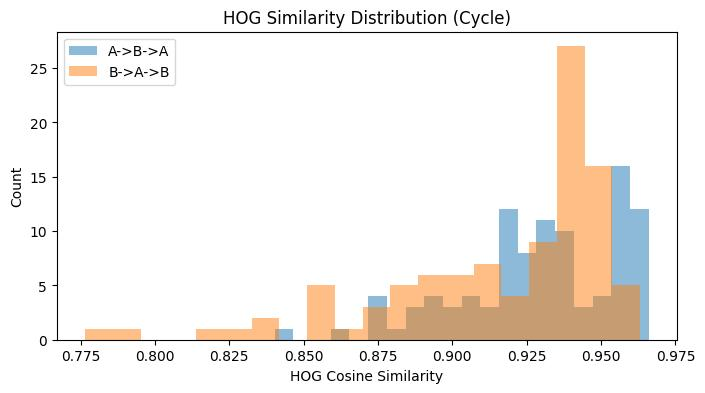

In [ ]:
# Function to compute HOG similarity for cycle translations
def compute_hog_cycle(dataset_path, G_forward, G_backward, num_images=100):
    image_paths = sorted([os.path.join(dataset_path, f)
                          for f in os.listdir(dataset_path) if f.endswith(('.jpg','.png'))])

    sims = []
    for i, img_path in enumerate(image_paths[:num_images]):
        img = Image.open(img_path).convert('RGB')
        img_tensor = transform(img).unsqueeze(0).cuda()

        with torch.no_grad():
            # Forward translation
            translated_tensor = G_forward(img_tensor)
            # Cycle reconstruction
            cycle_tensor = G_backward(translated_tensor)

        orig_np = to_numpy(img_tensor[0])
        cycle_np = to_numpy(cycle_tensor[0])

        sim = compute_hog_similarity(orig_np, cycle_np)
        sims.append(sim)

    return sims

# Compute HOG similarity for cycles
hog_cycle_A = compute_hog_cycle(dataset_A, G_A, G_B)
hog_cycle_B = compute_hog_cycle(dataset_B, G_B, G_A)

print(f"Average HOG similarity A->B->A cycle: {np.mean(hog_cycle_A):.4f}")
print(f"Average HOG similarity B->A->B cycle: {np.mean(hog_cycle_B):.4f}")

# Optional: plot histogram
plt.figure(figsize=(8,4))
plt.hist(hog_cycle_A, bins=20, alpha=0.5, label='A->B->A')
plt.hist(hog_cycle_B, bins=20, alpha=0.5, label='B->A->B')
plt.xlabel('HOG Cosine Similarity')
plt.ylabel('Count')
plt.title('HOG Similarity Distribution (Cycle)')
plt.legend()
plt.show()


**Observations:**  

The **cycle HOG similarity** measures how well the model preserves **structural features and gradients** after a full cycle of translation (A → B → A or B → A → B).  

These high values indicate that **the generators are able to maintain the structural integrity** of images over cyclic translations.  
Slightly lower similarity for **B → A → B** suggests that going from the minimalism to maximalism domain introduces **minor distortions**, likely due to the incorporation of higher texture and sophisticated detailing.

## MS-SSIM (Multi-Scale SSIM)
Captures perceptual similarity at multiple scales, useful for structural assessment over cycles.  


In [ ]:
!pip install pytorch-msssim

In [ ]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import os
from pytorch_msssim import ms_ssim  # pip install pytorch-msssim
import numpy as np

# ===== PATHS =====
dataset_A = "/content/drive/MyDrive/CycleGAN_Project/dataset/trainA"
dataset_B = "/content/drive/MyDrive/CycleGAN_Project/dataset/trainB"

G_A = model.netG_A  # A -> B
G_B = model.netG_B  # B -> A

# ===== TRANSFORMS =====
transform = transforms.Compose([
    transforms.Resize((286, 286)),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

def compute_ms_ssim(orig, out):
    # orig & out: torch tensors [C,H,W] in [-1,1]
    return ms_ssim(orig.unsqueeze(0).cuda(), out.unsqueeze(0).cuda(), data_range=2.0).item()

# ===== ACCUMULATORS =====
ms_ssim_A2B = []
ms_ssim_B2A = []
ms_ssim_cycle_A = []
ms_ssim_cycle_B = []

# ===== IMAGE PATHS =====
image_paths_A = sorted([os.path.join(dataset_A, f) for f in os.listdir(dataset_A) if f.endswith(('.jpg', '.png'))])
image_paths_B = sorted([os.path.join(dataset_B, f) for f in os.listdir(dataset_B) if f.endswith(('.jpg', '.png'))])

# ===== A → B & A → B → A =====
for i, img_path in enumerate(image_paths_A[:100]):
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).cuda()

    with torch.no_grad():
        translated_B = G_A(img_tensor.unsqueeze(0))[0]     # A → B
        recon_A = G_B(translated_B.unsqueeze(0))[0]        # B → A

    ms_ssim_A2B.append(compute_ms_ssim(img_tensor, translated_B))
    ms_ssim_cycle_A.append(compute_ms_ssim(img_tensor, recon_A))

# ===== B → A & B → A → B =====
for i, img_path in enumerate(image_paths_B[:100]):
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).cuda()

    with torch.no_grad():
        translated_A = G_B(img_tensor.unsqueeze(0))[0]     # B → A
        recon_B = G_A(translated_A.unsqueeze(0))[0]        # A → B

    ms_ssim_B2A.append(compute_ms_ssim(img_tensor, translated_A))
    ms_ssim_cycle_B.append(compute_ms_ssim(img_tensor, recon_B))

# ===== PRINT RESULTS =====
print(f"Average MS-SSIM (A→B): {np.mean(ms_ssim_A2B):.4f}")
print(f"Average MS-SSIM (B→A): {np.mean(ms_ssim_B2A):.4f}")
print(f"Average Cycle MS-SSIM (A→B→A): {np.mean(ms_ssim_cycle_A):.4f}")
print(f"Average Cycle MS-SSIM (B→A→B): {np.mean(ms_ssim_cycle_B):.4f}")


Average MS-SSIM (A→B): 0.4228
Average MS-SSIM (B→A): 0.6034
Average Cycle MS-SSIM (A→B→A): 0.9463
Average Cycle MS-SSIM (B→A→B): 0.9692


**Observations:**  
  
The relatively lower MS-SSIM values for translations indicate that there are perceptual differences being introduced, especially in **A → B**, likely due to the maximalism → minimalism direction, as MS-SSIM penalizes feature loss more than feature addition.

The **cycle MS-SSIM scores** are very high, demonstrating that **the model preserves structural and perceptual consistency well** when images are translated back to their original domain.

In [ ]:
import os
from PIL import Image
import numpy as np
from skimage import color
import torchvision.transforms as transforms
import torch

# ===== PATHS =====
dataset_A = "/content/drive/MyDrive/CycleGAN_Project/dataset/trainA"
dataset_B = "/content/drive/MyDrive/CycleGAN_Project/dataset/trainB"

G_A = model.netG_A  # A -> B
G_B = model.netG_B  # B -> A

# ===== PREPROCESSING =====
transform = transforms.Compose([
    transforms.Resize((286, 286)),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

def tensor_to_lab(img_tensor):
    """Convert tensor [-1,1] -> Lab color space."""
    img = (img_tensor.clamp(-1, 1).cpu().permute(1, 2, 0).numpy() + 1) / 2
    img = (img * 255).astype(np.uint8)
    return color.rgb2lab(img)

def compute_delta_e(orig_tensor, recon_tensor):
    """Compute mean Delta-E between two tensors."""
    lab_orig = tensor_to_lab(orig_tensor)
    lab_recon = tensor_to_lab(recon_tensor)
    delta_e = color.deltaE_cie76(lab_orig, lab_recon)
    return np.mean(delta_e)

# ===== ACCUMULATORS =====
delta_A2B = []
delta_B2A = []
delta_cycle_A = []
delta_cycle_B = []

# ===== IMAGE PATHS =====
image_paths_A = sorted([os.path.join(dataset_A, f) for f in os.listdir(dataset_A) if f.endswith(('.jpg', '.png'))])
image_paths_B = sorted([os.path.join(dataset_B, f) for f in os.listdir(dataset_B) if f.endswith(('.jpg', '.png'))])

# ===== A → B and A → B → A =====
for i, img_path in enumerate(image_paths_A[:100]):
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).cuda()
    with torch.no_grad():
        fake_B = G_A(img_tensor.unsqueeze(0))[0]
        recon_A = G_B(fake_B.unsqueeze(0))[0]
    delta_A2B.append(compute_delta_e(img_tensor, fake_B))
    delta_cycle_A.append(compute_delta_e(img_tensor, recon_A))

# ===== B → A and B → A → B =====
for i, img_path in enumerate(image_paths_B[:100]):
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).cuda()
    with torch.no_grad():
        fake_A = G_B(img_tensor.unsqueeze(0))[0]
        recon_B = G_A(fake_A.unsqueeze(0))[0]
    delta_B2A.append(compute_delta_e(img_tensor, fake_A))
    delta_cycle_B.append(compute_delta_e(img_tensor, recon_B))

# ===== PRINT RESULTS =====
print(f"Average Delta-E (A→B): {np.mean(delta_A2B):.4f}")
print(f"Average Delta-E (B→A): {np.mean(delta_B2A):.4f}")
print(f"Average Delta-E Cycle (A→B→A): {np.mean(delta_cycle_A):.4f}")
print(f"Average Delta-E Cycle (B→A→B): {np.mean(delta_cycle_B):.4f}")


Average Delta-E (A→B): 19.2697
Average Delta-E (B→A): 15.9751
Average Delta-E Cycle (A→B→A): 5.4081
Average Delta-E Cycle (B→A→B): 3.9653


**Observations:**  

**Delta-E** measures **perceptual color differences** between images, where lower values indicate better color fidelity.  

The higher Delta-E values for **direct translations** show that some **color deviations** occur during domain translation.

The **cycle translations** exhibit much lower Delta-E values, confirming that the **model maintains color consistency** when images are mapped back to their original domain.

## **Training Loss Visualization**

During CycleGAN training, several losses are monitored to ensure stable and effective learning. These include:

- **Generator losses:** `G_A`, `G_B`  
- **Discriminator losses:** `D_A`, `D_B`  
- **Cycle-consistency losses:** `cycle_A`, `cycle_B`   

The plot below shows the average value of each loss per epoch over the training period.  


Found losses in log: ['G_A', 'G_B', 'D_A', 'D_B', 'cycle_A', 'cycle_B']


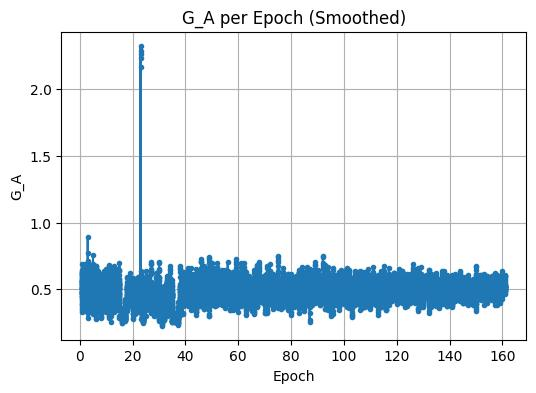

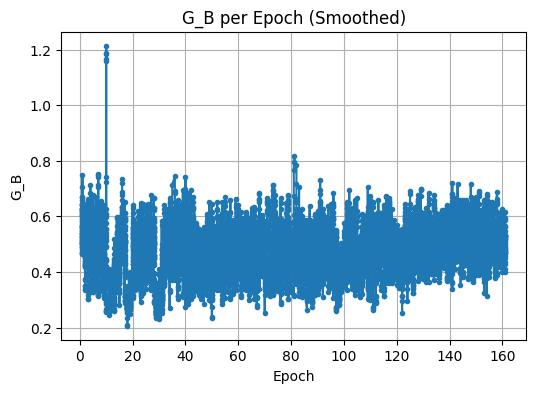

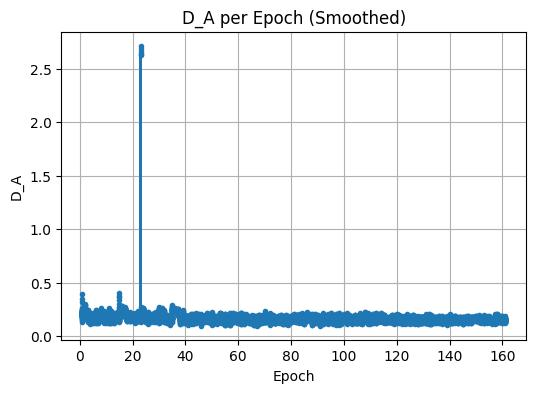

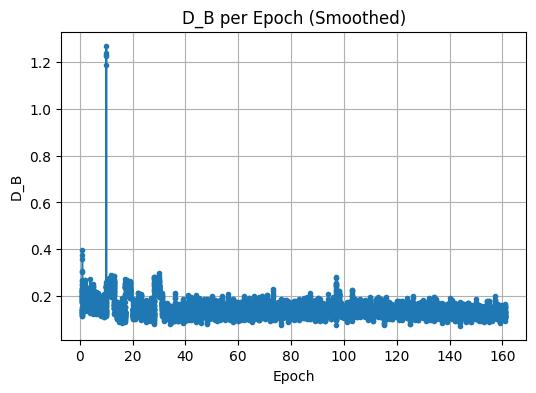

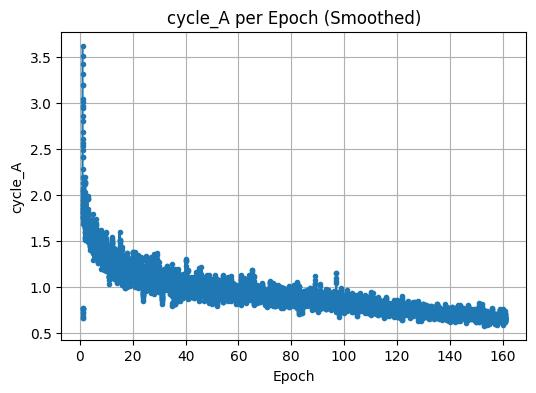

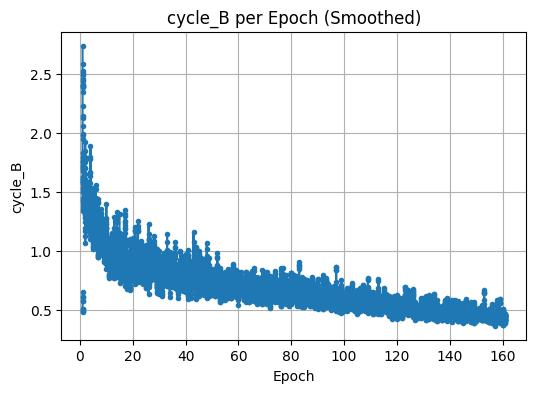

In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

log_file = "/content/drive/MyDrive/CycleGAN_Project/checkpoints/bridal_cyclegan/loss_log.txt"
assert os.path.exists(log_file), "Loss log file not found!"

# ----------------------------
# Parse the log
# ----------------------------
data = []

with open(log_file, 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        # Extract epoch
        epoch_match = re.search(r'epoch[: ]+(\d+)', line)
        epoch = int(epoch_match.group(1)) if epoch_match else np.nan

        # Extract all key:value pairs
        pairs = re.findall(r'(\w+):\s*([\d\.\-e]+)', line)
        row = {'epoch': epoch}
        for k, v in pairs:
            try:
                row[k] = float(v)
            except:
                row[k] = np.nan
        data.append(row)

df = pd.DataFrame(data)

# ----------------------------
# Select only the losses you actually trained
# ----------------------------
loss_names = ['G_A', 'G_B', 'D_A', 'D_B', 'cycle_A', 'cycle_B']
existing_losses = [loss for loss in loss_names if loss in df.columns]

print(f"Found losses in log: {existing_losses}")

# ----------------------------
# Smoothing function
# ----------------------------
def smooth(y, window=5):
    return y.rolling(window=window, min_periods=1, center=True).mean()

# ----------------------------
# Plot each loss separately
# ----------------------------
for loss in existing_losses:
    plt.figure(figsize=(6,4))
    plt.plot(df['epoch'], smooth(df[loss]), marker='o', markersize=3, linestyle='-')
    plt.title(f'{loss} per Epoch (Smoothed)')
    plt.xlabel('Epoch')
    plt.ylabel(loss)
    plt.grid(True)
    plt.show()


**Observations: Loss Evolution**  

- The **discriminator losses** for both domains (A and B) exhibit **minimal oscillations**, which suggests **early stabilization** despite the dataset's visual complexity.  
- The **generator losses** show more noticeable oscillations, reflecting that the generator is **continuously adapting to intricate details** in the images.  
- The **cycle-consistency loss** decreases steadily throughout training, indicating **progressive improvement in structural preservation** across translations.
